# scTRAM Benchmarking for HDCA (Human Developmental Cell Atlas)

In [22]:
0

0

In [2]:
import sys

working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import gc
import itertools
import logging
import os
import pickle
import subprocess
import sqlite3
import time
import h5py

from pandas.api.types import is_object_dtype
import anndata as ad
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import tqdm

import scvelo as scv
import cellrank as cr
import scanpy.external as sce

scv.settings.verbosity = 3
cr.settings.verbosity = 2
sc.settings.verbose = 3

In [3]:
from helper.get_hdca_trainings_with_paths import get_hdca_trainings_with_paths
from helper.pickle_operations import save_pickle_bundle, load_pickle_bundle
from helper.csv_operations import (
    harmonize_union_with_report,
    analyze_column_consistency,
    combine_dataframes_on_columns
)

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")
from incremental_training.helper.constants import metrics_scib, metric_direction_dict

2025-08-08 13:37:44.948 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-08-08 13:37:44.949 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [4]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import colorcet as cc
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from matplotlib import gridspec
from networkx.drawing.nx_agraph import graphviz_layout

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import colorcet as cc
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
def is_job_running(job_name):
    result = subprocess.run(
        ["squeue", "-o", "%.28i %.28j %.28u %R", "-u", "kemal.inecik"], capture_output=True, text=True
    )
    jobs = [[j.strip() for j in i.split()] for i in result.stdout.strip().split("\n")]
    for jobid, jobname, jobuser, jobnode in jobs:
        if job_name == jobname:
            return True
    return False

In [6]:
os.getcwd()

'/ictstr01/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments/development_atlas_figure'

In [7]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

In [8]:
pickle_bundle_path = os.path.join(dataset_dir, "_experiment_development_atlas_helper_pickle_bundle.pkl")
(
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories,
    ground_truth_trajectories_annotation_level,
    trajectory_subset_dict
) = load_pickle_bundle(pickle_bundle_path)

## Check

In [9]:
trajectory_focus = "Haem_ref"

with h5py.File(df_hdca_component_adata_paths["Suo"]["latent"]) as f:
    adata_scvi_latent_obs = ad.io.read_elem(f["obs"])

little = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, include_additional_nodes=True)
suo_nodes = set(out_df.loc[adata_scvi_latent_obs.index][ground_truth_trajectories_annotation_level[trajectory_focus]])

trajectory_focus, np.all([i_little in suo_nodes for i_little in little.nodes()])

('Haem_ref', True)

In [10]:
trajectory_focus = "germline"

with h5py.File(df_hdca_component_adata_paths["Garcia"]["latent"]) as f:
    adata_scvi_latent_obs = ad.io.read_elem(f["obs"])

little = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, include_additional_nodes=True)
suo_nodes = set(out_df.loc[adata_scvi_latent_obs.index][ground_truth_trajectories_annotation_level[trajectory_focus]])

trajectory_focus, np.all([i_little in suo_nodes for i_little in little.nodes()])

('germline', True)

In [11]:
trajectory_focus = "pns_neuro"

with h5py.File(df_hdca_component_adata_paths["Lawrence"]["latent"]) as f:
    adata_scvi_latent_obs = ad.io.read_elem(f["obs"])

little = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, include_additional_nodes=True)
suo_nodes = set(out_df.loc[adata_scvi_latent_obs.index][ground_truth_trajectories_annotation_level[trajectory_focus]])

trajectory_focus, np.all([i_little in suo_nodes for i_little in little.nodes()])

('pns_neuro', False)

In [12]:
other_nodes = {i_little for i_little in little.nodes() if i_little not in suo_nodes}
display(other_nodes)
out_df[out_df[ground_truth_trajectories_annotation_level[trajectory_focus]].isin(other_nodes)].value_counts(["handle_anndata"])

{'Autonomic_neuronal_progenitor', 'Enteric_neuron'}

handle_anndata
Suo               587
Yu                445
Colin              76
Dong               43
Kanemaru           10
He                  3
To                  2
Zhang               2
Braun               0
Calvanese           0
Garcia              0
Lawrence            0
Miller              0
Sridhar             0
Name: count, dtype: int64

# functions

In [13]:
from scipy import stats
import numpy as np
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_correlation(
        df,
        x_col: str,
        y_col: str,
        x_col_label: str,
        y_col_label: str,
        method: str = "spearman",
        title: str | None = None,
        marker_size: int = 40,
        figsize: tuple[int, int] = (4, 4),
        n_ticks: int = 5,             # how many ticks you want on each axis
        **scatter_kws
    ):
    # ── 1) Clean data ───────────────────────────────────────────────────────
    clean = df[[x_col, y_col]].dropna()
    if clean.empty:
        raise ValueError("All x/y pairs are NaN — nothing to plot or fit.")

    x, y = clean[x_col], clean[y_col]

    # ── 2) Fit & correlation ────────────────────────────────────────────────
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    corr_coef = clean.corr(method=method).iloc[0, 1]

    # ── 3) Prepare equal limits & ticks ─────────────────────────────────────
    data_min = min(x.min(), y.min())
    data_max = max(x.max(), y.max())
    pad      = 0.05 * (data_max - data_min) if data_max > data_min else 1.0
    lower, upper = data_min - pad, data_max + pad

    ticks = np.linspace(lower, upper, n_ticks)

    sci1 = FuncFormatter(lambda v, _pos: f"{v:.1e}")   # 1-digit scientific

    # ── 4) Plot ─────────────────────────────────────────────────────────────
    plt.figure(figsize=figsize)

    sns.scatterplot(
        data=clean,
        x=x_col, y=y_col,
        s=marker_size, color="black",
        edgecolor="white", linewidth=0.6, alpha=0.8, zorder=2,
        **scatter_kws,
    )
    sns.regplot(
        data=clean,
        x=x_col, y=y_col,
        scatter=False, color="darkred",
        line_kws={"linewidth": 0.81},
    )

    ax = plt.gca()
    sns.despine(trim=False)

    # Square axes & matching limits
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(lower, upper);  ax.set_xticks(ticks);  ax.xaxis.set_major_formatter(sci1)
    ax.set_ylim(lower, upper);  ax.set_yticks(ticks);  ax.yaxis.set_major_formatter(sci1)
    ax.tick_params(labelbottom=False, labelleft=False)   # remove labels only

    # Labels & title
    ax.set_xlabel(x_col_label, fontsize=10, labelpad=10)
    ax.set_ylabel(y_col_label, fontsize=10, labelpad=10)
    if title is None:
        title = (f"{method.capitalize()} ρ = {corr_coef:.2f}   |   Slope = {slope:.3f}")
    ax.set_title(title, fontsize=10, pad=12)

    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

    return slope, intercept

In [14]:
from math import sqrt
def plot_trajectory(
    G,
    title="trajectory_name",
    figsize=None,
    font_size=10,
    node_size=300,
    node_color="#8DA0CB",  # Modern muted blue
    cmap="viridis",
    color_nodes_by_position=False,
    # Edge styling parameters
    edge_width=1,
    edge_color="gray",
    color_edges_by_weight=False,
    edge_weight_attribute="weight",
    edge_cmap="plasma",
    edge_vmin=None,
    edge_vmax=None,
    edge_colorbar=True,
    edge_labels=False,
    edge_label_format=".2f",
    edge_label_font_size=8,
    edge_label_color="black",
    edge_label_offset=None,
    # Layout parameters
    label_offset=None,
    title_y=1.02,
    layout_args="-Grankdir=LR -Gnodesep=0.25 -Granksep=0.25",
):
    
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args=layout_args)
    x_coords = [pos[node][0] for node in G.nodes()] if G.nodes() else []
    y_coords = [pos[node][1] for node in G.nodes()] if G.nodes() else []

    # Create actual figure with determined size
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    # Node coloring logic
    if color_nodes_by_position:
        try:
            min_x, max_x = min(x_coords), max(x_coords)
            color_vals = [(x - min_x) / (max_x - min_x) if max_x != min_x else 0.5 for x in x_coords]
            node_color = plt.get_cmap(cmap)(color_vals)
        except Exception as e:
            print(f"Warning: Positional node coloring failed - {e}. Using base color.")

    # Edge coloring logic
    if color_edges_by_weight:
        weights = [G[u][v].get(edge_weight_attribute, 1.0) for u, v in G.edges]
        edge_vmin = edge_vmin if edge_vmin is not None else (min(weights) if weights else 0)
        edge_vmax = edge_vmax if edge_vmax is not None else (max(weights) if weights else 1)
        norm = mpl.colors.Normalize(vmin=edge_vmin, vmax=edge_vmax)
        cmap_edge = plt.get_cmap(edge_cmap)
        edge_colors = [cmap_edge(norm(w)) for w in weights]
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_edge)
        sm.set_array(weights)
    else:
        edge_colors = edge_color
        sm = None

    # Label positioning offsets
    if label_offset is None:
        label_offset = 0

    if edge_label_offset is None:
        edge_label_offset = 0

    # Calculate final label positions
    label_pos = {n: (x, y + label_offset) for n, (x, y) in pos.items()}

    # Draw nodes and edges
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=node_size, node_color=node_color, edgecolors="black", linewidths=0.8, alpha=1.0
    )

    node_radius = sqrt(node_size) / 2.0
    
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        # arrowstyle="-|>",
        # arrowsize=4,
        edge_color=edge_colors,
        width=edge_width,
        alpha=1.0,
        connectionstyle="arc3",
        arrows=False,  
        # # chop off exactly one node‐radius at each end
        # min_source_margin=node_radius,
        # min_target_margin=node_radius,
    )

    # Edge label placement
    if edge_labels:
        for u, v in G.edges():
            if edge_weight_attribute not in G[u][v]:
                continue
            weight = G[u][v][edge_weight_attribute]
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            dx, dy = x2 - x1, y2 - y1
            length = (dx**2 + dy**2) ** 0.5
            if length == 0:
                continue  # Skip self-loops
            # Calculate perpendicular offset position
            mid_x = (x1 + x2) / 2 + (dy / length) * edge_label_offset
            mid_y = (y1 + y2) / 2 - (dx / length) * edge_label_offset
            ax.text(
                mid_x,
                mid_y,
                f"{weight:{edge_label_format}}",
                fontsize=edge_label_font_size,
                color=edge_label_color,
                ha="center",
                va="center",
                # bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
            )

    # Edge weight colorbar
    if color_edges_by_weight and edge_colorbar and sm:
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.3, aspect=40, pad=0.05)
        cbar.set_label("Edge Weight", fontsize=font_size)
        cbar.ax.tick_params(labelsize=font_size - 2)

    fig.suptitle(title, y=title_y, fontsize=font_size + 2, fontweight="bold", color="#333333")

    # Final layout adjustments
    plt.subplots_adjust(
        left=0.03, right=0.97, top=0.97, bottom=0.15 if (color_edges_by_weight and edge_colorbar) else 0.03
    )
    ax.set_axis_off()
    plt.show()

In [15]:
def get_winners(row):
    metric = row['metric']
    direction = metric_direction_dict[metric]
    c = row['score_Component']
    a = row['score_Atlas']
    
    if direction == 'increasing':
        if c > a:
            return pd.Series([0, 1])
        elif a > c:
            return pd.Series([1, 0])
        else:
            return pd.Series([0.5, 0.5])
    elif direction == 'decreasing':
        if c < a:
            return pd.Series([0, 1])
        elif a < c:
            return pd.Series([1, 0])
        else:
            return pd.Series([0.5, 0.5])
    else:
        return pd.Series([None, None])  # In case metric not found

In [16]:
def get_nodes_edges(row):
    trj_name = row['booted_trajectory']
    len_nodes, len_edges = trj_size_dict[trj_name]
    return pd.Series([len_nodes, len_edges])

In [17]:
def cr_calc(adata_cr, root_cell_type, i, ann_levl):
    sc.tl.pca(adata_cr, n_comps=11, svd_solver='arpack')
    sce.tl.palantir(adata_cr, n_components=10, knn=30)

    root_cells = adata_cr.obs_names[adata_cr.obs[ann_levl] == root_cell_type]
    if len(root_cells) == 0:
        raise ValueError(f"No cells found with {ann_levl!r} == {root_cell_type!r}")
    start_cell = root_cells[i]
    
    pr_res = sce.tl.palantir_results(
        adata_cr,
        early_cell=start_cell,
        ms_data="X_palantir_multiscale",
        knn=30,
        num_waypoints=1200,
        n_jobs=-1
    )
    adata_cr.obs["palantir_pseudotime"] = pr_res.pseudotime

    pk = cr.kernels.PseudotimeKernel(adata_cr, time_key='palantir_pseudotime')
    pk.compute_transition_matrix()
    return pk    

# running sctram

In [18]:
trajectory_focus_list = {
    "Haem_ref": "Suo",
    "germline": "Garcia",
}

In [19]:
override = False

count = 0
memory_needed = 297
run_id = "fig2comp"
warning_already_exist = []

for trajectory_focus, anndata_subset in trajectory_focus_list.items():

    trajectory_annotation_column = ground_truth_trajectories_annotation_level[trajectory_focus]

    for decompose_method in ["2"]:

        input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            litc = pickle.load(_file)

        booted_trajectory_list = litc.graph["trajectories"]
        
        for booted_trajectory in booted_trajectory_list:

            base_job_name = f"{run_id}_c1_{trajectory_focus}_c2_{anndata_subset}_c3{decompose_method}_c4{booted_trajectory}"
            output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")
            log_file = os.path.join(logs_directory, f"slurm_out_metric_sctram_{base_job_name}.log")
            slurmjob_name = base_job_name
        
            if override or not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
                try:
                    slurm_script = f"""#!/bin/bash
#SBATCH -J {slurmjob_name}
#SBATCH -p cpu_p
#SBATCH --qos cpu_normal
#SBATCH -c 4
#SBATCH --mem=293G
#SBATCH --nice=0
#SBATCH -t 5:55:55
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate sctram_dev_env
python -u {os.path.join(helpers_directory, 'sctram_runner_comp.py')} --decompose_method "{decompose_method}" --run_id "{run_id}" --booted_trajectory "{booted_trajectory}" --trajectory "{trajectory_focus}" --anndata_subset "{anndata_subset}" --trajectory_annotation_column "{trajectory_annotation_column}" 
"""
                    slurm_script_name = os.path.join(logs_directory, f"slurm_job_metric_sctram_{base_job_name}.sh")
                    with open(slurm_script_name, "w") as _file_slurm_script:
                        _file_slurm_script.write(slurm_script)
    
                    print(f"Submitted job: {base_job_name!r}")
                    subprocess.run(["sbatch", slurm_script_name])
                    count += 1
                finally:
                    time.sleep(0.05)
                    os.remove(slurm_script_name)
            else:
                warning_already_exist.append(base_job_name)

print(f" - Number of jobs already exist: {len(warning_already_exist)}")
print(f" - Number of jobs submitted: {count}")

 - Number of jobs already exist: 95
 - Number of jobs submitted: 0


# reading it

In [20]:
result_df_main = pd.DataFrame()
count = 0
run_id = "fig2comp"

for trajectory_focus, anndata_subset in trajectory_focus_list.items():

    for decompose_method in ["2"]:

        input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            litc = pickle.load(_file)

        booted_trajectory_list = litc.graph["trajectories"]
        
        for booted_trajectory in booted_trajectory_list:

            base_job_name = f"{run_id}_c1_{trajectory_focus}_c2_{anndata_subset}_c3{decompose_method}_c4{booted_trajectory}"
            output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")

            if not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
                print(f"Not exist: {base_job_name!r}")
            else:
                count += 1
                df_trajectory_obsm = pd.read_pickle(output_file_path)
                df_trajectory_obsm["anndata_subset"] = anndata_subset
                df_trajectory_obsm["trajectory"] = trajectory_focus
                df_trajectory_obsm["trajectory_annotation_column"] = trajectory_annotation_column
                df_trajectory_obsm["decompose_method"] = decompose_method
                df_trajectory_obsm["booted_trajectory"] = booted_trajectory
                result_df_main = pd.concat([result_df_main, df_trajectory_obsm])

result_df_main.reset_index(drop=True, inplace=True)
result_df_main['score'] = pd.to_numeric(result_df_main['score'], errors='raise')
trajectory_label_mapping = {
    "B_lin": "Hematopoietic Lineage",
    "Ery": "Hematopoietic Lineage",
    "Haem_broad": "Hematopoietic Lineage",
    "Haem_ref": "Hematopoietic Lineage",
    "pns_glia": "Peripheral Nervous System",
    "pns_neuro": "Peripheral Nervous System",
    "germline": "Germline"
}
result_df_main["trajectory_class"] = pd.Series([trajectory_label_mapping[i] for i in result_df_main["trajectory"]])
column_to_sort = ["decompose_method", "trajectory_class", "trajectory", "booted_trajectory", "path", "metric", "anndata_subset", "trajectory_annotation_column", "score"]
result_df_main.sort_values(by=column_to_sort, inplace=True, ignore_index=True)
result_df_main = result_df_main[column_to_sort]

print(f" - Number of jobs read: {count}")

 - Number of jobs read: 95


In [23]:
result_df_main.to_pickle(os.path.join(dataset_dir, f"df_boots_fig2_calculations_for_individuals.pkl"))

In [21]:
result_df_boot_path = os.path.join(dataset_dir, f"df_boots_fig2_calculations.pkl")
result_df_boot = pd.read_pickle(result_df_boot_path)
result_df_boot = result_df_boot[result_df_boot["representation"]=="scvi"]
result_df_boot.reset_index(inplace=True, drop=True)

# focus_traj

In [24]:
focus_trajectory = "germline"

df_compo = result_df_main[result_df_main["trajectory"] == focus_trajectory]
df_atlas = result_df_boot[result_df_boot["trajectory"] == focus_trajectory]

df_atlas.reset_index(inplace=True, drop=True)
df_compo.reset_index(inplace=True, drop=True)

decompose_method = "2"
input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{focus_trajectory}_litc_{decompose_method}.pkl")
with open(input_trajectories_path_litc, 'rb') as _file:
    lit = pickle.load(_file)

trj_size_dict = dict()
for trj_name in lit.graph['trajectories']:
    trj_size_dict[trj_name] = len(lit.get_trajectory(trj_name, False).nodes()), len(lit.get_trajectory(trj_name, False).edges())

assert df_compo.shape == df_atlas.shape
for i in range(len(df_compo)):
    i1 = list(df_atlas.iloc[i][["booted_trajectory", "metric"]])
    i2 = list(df_compo.iloc[i][["booted_trajectory", "metric"]])
    assert i1==i2

# df_both

df_both = df_compo.copy()
del df_both["score"]
df_both["score_Component"] = list(df_compo["score"])
df_both["score_Atlas"] = list(df_atlas["score"])
df_both.reset_index(inplace=True, drop=True)
del df_both["anndata_subset"]
df_both[['winner_Component', 'winner_Atlas']] = df_both.apply(get_winners, axis=1)
df_both[['len_nodes', 'len_edges']] = df_both.apply(get_nodes_edges, axis=1)

label_mapping_o = {
    "adjacency": "Adjacency",
    "embedding": "Embedding",
    "pseudotime": "Pseudotime",
}
df_both["path"] = [label_mapping_o[i] for i in df_both["path"]]

# long_both

id_cols = [
    "decompose_method", "trajectory_class", "trajectory",
    "booted_trajectory", 'len_nodes', 'len_edges', "path", "metric", 
    "trajectory_annotation_column"
]
_df = df_both.reset_index()  
id_cols = ["index"] + id_cols
long_both = (
    pd.wide_to_long(
        _df,                       # the original wide dataframe
        stubnames=["score", "winner"],
        i=id_cols,                # columns that make a unique row
        j="focus",               # new column: 'component' or 'atlas'
        sep="_",                  # underscore separates stub & suffix
        suffix="(Component|Atlas)"  # the two suffix values to capture
    )
    .reset_index()
    .sort_values(id_cols + ["focus"])   # optional tidy ordering
)
del long_both["index"]

# df_edges

df_edges = []
for ind, row in long_both.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)
df_edges_pivot_rank = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='focus', values='winner')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()
trj = InputTrajectories(ground_truth_trajectories).get_trajectory(focus_trajectory, False)
for (from_cell, to_cell), representations in df_edges_pivot_rank_mean.iterrows():
    for representation, score in representations.items():
        trj[from_cell][to_cell][f"weight_{representation}"] = score

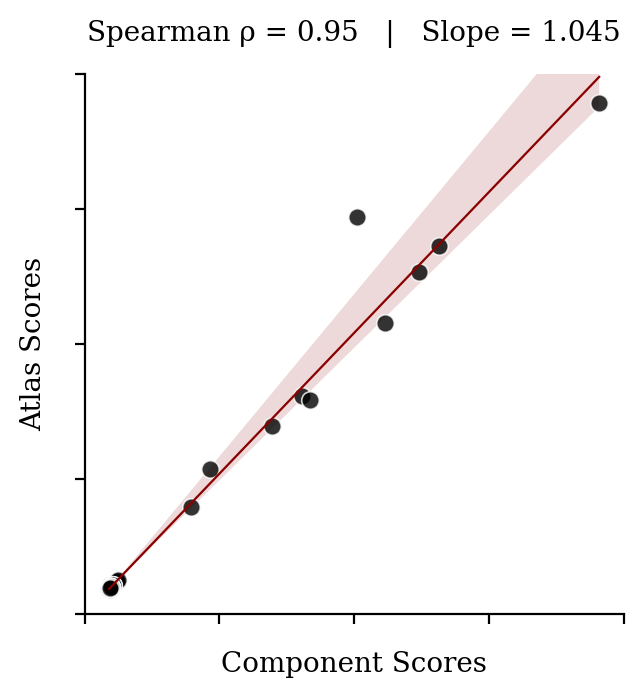

Slope: 1.0447, intercept: 0.0411


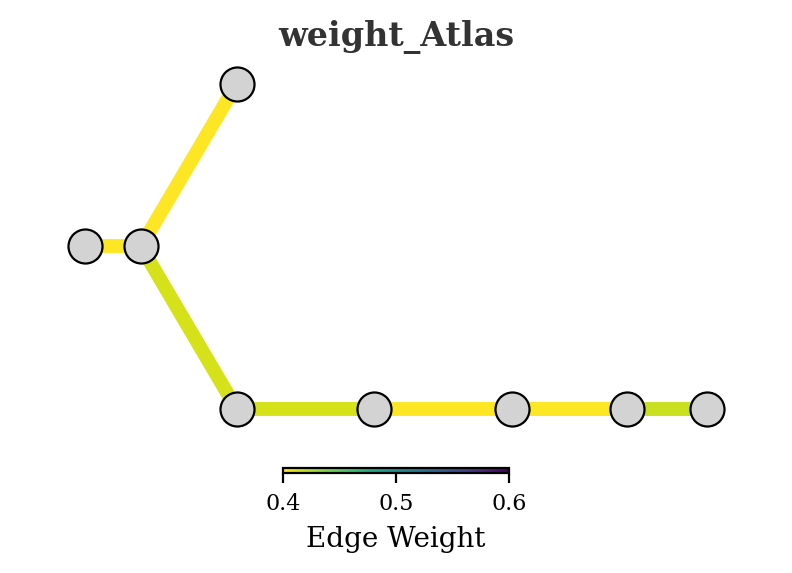

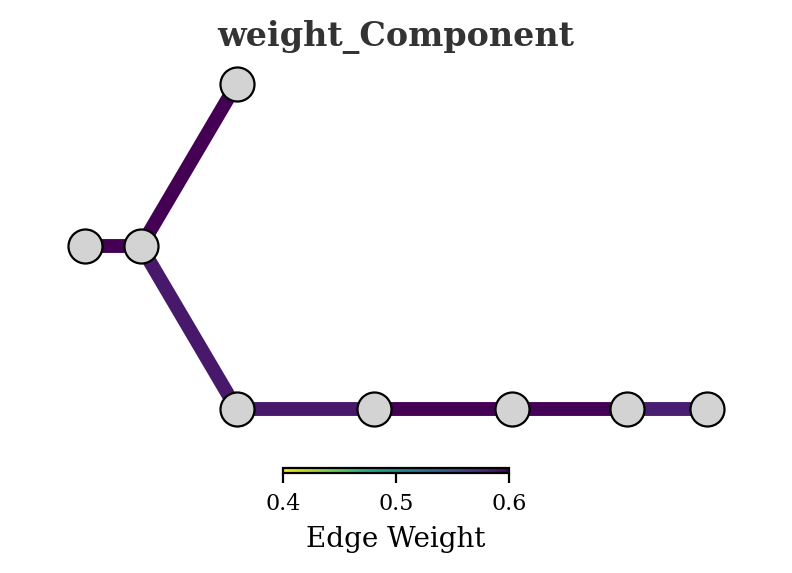

In [25]:
m, b = plot_correlation(df_both, "score_Component", "score_Atlas", "Component Scores", "Atlas Scores")
print(f"Slope: {m:.4f}, intercept: {b:.4f}")

for i in ['weight_Atlas', 'weight_Component']:
    plot_trajectory(
        trj, 
        figsize=(4, 3),
        edge_weight_attribute=i,
        title=i, 
        edge_vmin=0.4,
        edge_vmax=0.6,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=True
    )

/tmp/ipykernel_1291460/3224950903.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bp = sns.barplot(
/tmp/ipykernel_1291460/3224950903.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


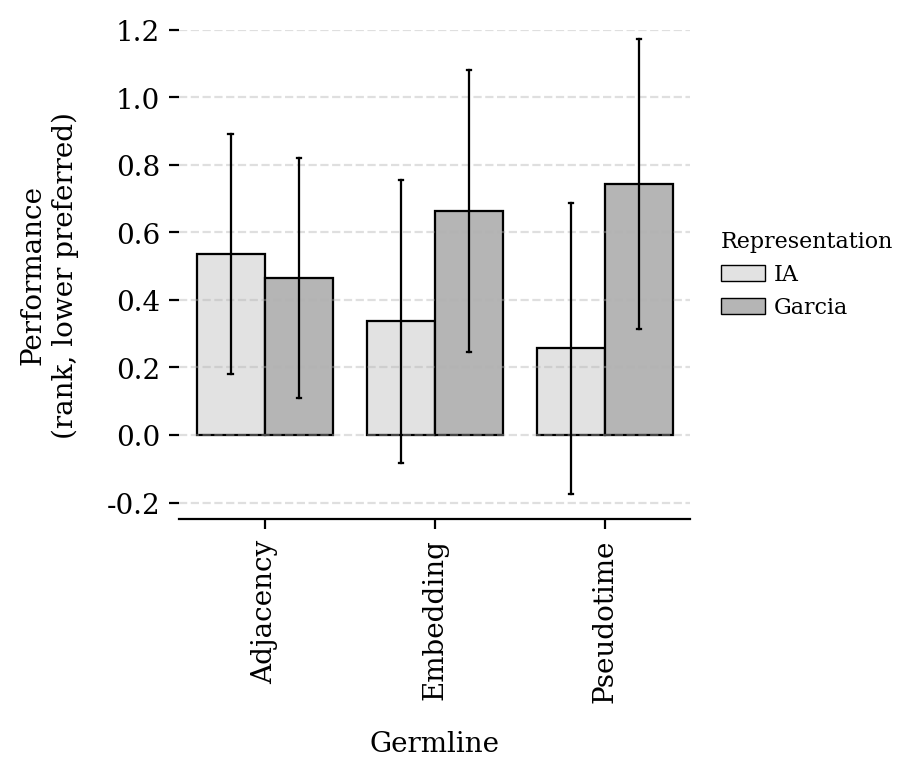

In [26]:
label_mapping = {
    "Atlas": "IA",
    "Component": "Garcia",
}

# match boxplot’s height & per-column width
fig_height = 4
n_cols = long_both["focus"].nunique()
col_width = 2.8
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=long_both,
    hue="focus",
    y="winner",
    x="path",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Germline', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(-0.25, 1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Representation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [27]:
long_both_germ = long_both.copy()

In [28]:
long_both.groupby(["booted_trajectory", "focus"]).mean(["winner"])

len_nodes  len_edges     score    winner
booted_trajectory   focus                                              
germline_subgraph_0 Atlas            3.0        2.0  4.185202  0.354167
                    Component        3.0        2.0  4.158372  0.645833
germline_subgraph_1 Atlas            3.0        2.0  3.922190  0.322917
                    Component        3.0        2.0  4.119144  0.677083
germline_subgraph_2 Atlas            7.0        6.0  8.918243  0.395833
                    Component        7.0        6.0  8.974849  0.604167
germline_subgraph_3 Atlas            6.0        5.0  7.220548  0.520833
                    Component        6.0        5.0  5.035665  0.479167
germline_subgraph_4 Atlas            3.0        2.0  3.467935  0.354167
                    Component        3.0        2.0  3.436826  0.645833
germline_subgraph_5 Atlas            3.0        2.0  2.779200  0.437500
                    Component        3.0        2.0  2.364890  0.562500
germline_subgraph_6 Atlas            3.0        2.0  5.478562  0.416667
                    Component        3.0        2.0  5.610168  0.583333
germline_subgraph_7 Atlas            7.0        6.0  6.442891  0.395833
                    Component        7.0        6.0  6.333666  0.604167
germline_subgraph_8 Atlas            8.0        7.0  6.768070  0.375000
                    Component        8.0        7.0  6.559733  0.625000
germline_subgraph_9 Atlas            3.0        2.0  2.018169  0.395833
                    Component        3.0        2.0  2.018197  0.604167

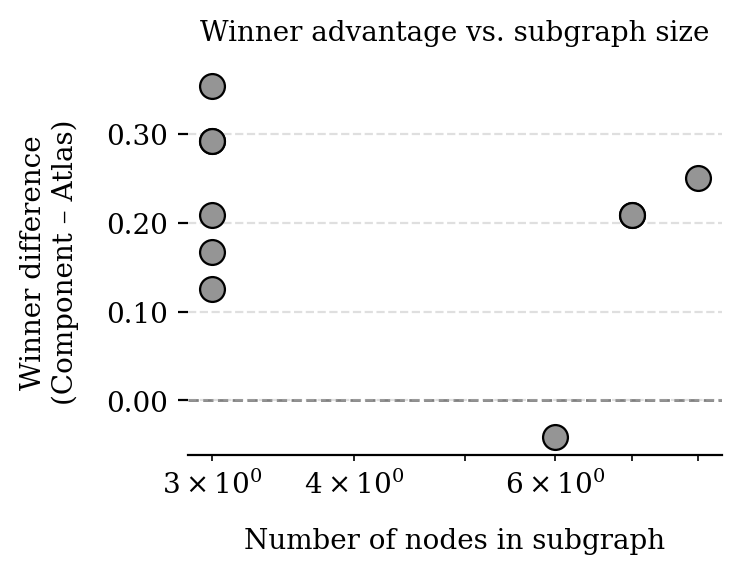

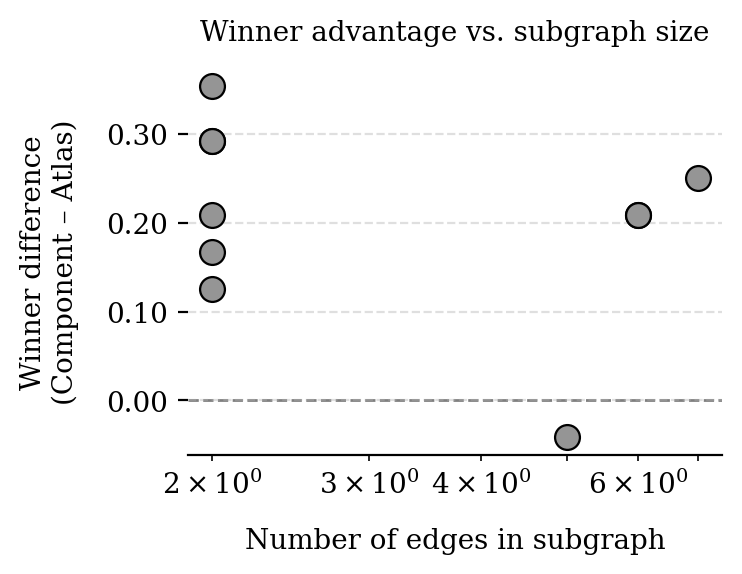

In [29]:
for what in ["nodes", "edges"]:
    fig_height = 3
    fig_width = 4.5  # Adjust as needed
    
    # Compute pivot as before
    pivot = (
        long_both
          .pivot_table(index=['booted_trajectory', f'len_{what}'],
                       columns='focus',
                       values='winner')
          .reset_index()
    )
    pivot['winner_diff'] = pivot['Component'] - pivot['Atlas']
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Draw scatter
    palette = sns.color_palette("Greys", n_colors=3)
    ax.scatter(pivot[f'len_{what}'], pivot['winner_diff'], s=80, 
               color=palette[1], edgecolor="black", linewidth=0.81, zorder=2)
    
    # Axes & labels
    ax.axhline(0, linestyle='--', linewidth=1, color='black', alpha=0.5, zorder=1)
    ax.set_xlabel(f"Number of {what} in subgraph", fontsize=10, labelpad=10)
    ax.set_ylabel("Winner difference\n(Component – Atlas)", fontsize=10, labelpad=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)
    ax.set_title("Winner advantage vs. subgraph size", fontsize=10, pad=10)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # Grid and despine
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(left=True, trim=False)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.xscale("log")
    plt.show()


# focus-2

In [30]:
focus_trajectory = "Haem_ref"

df_compo = result_df_main[result_df_main["trajectory"] == focus_trajectory]
df_atlas = result_df_boot[result_df_boot["trajectory"] == focus_trajectory]

df_atlas.reset_index(inplace=True, drop=True)
df_compo.reset_index(inplace=True, drop=True)

decompose_method = "2"
input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{focus_trajectory}_litc_{decompose_method}.pkl")
with open(input_trajectories_path_litc, 'rb') as _file:
    lit = pickle.load(_file)

trj_size_dict = dict()
for trj_name in lit.graph['trajectories']:
    trj_size_dict[trj_name] = len(lit.get_trajectory(trj_name, False).nodes()), len(lit.get_trajectory(trj_name, False).edges())

assert df_compo.shape == df_atlas.shape
for i in range(len(df_compo)):
    i1 = list(df_atlas.iloc[i][["booted_trajectory", "metric"]])
    i2 = list(df_compo.iloc[i][["booted_trajectory", "metric"]])
    assert i1==i2

# df_both

df_both = df_compo.copy()
del df_both["score"]
df_both["score_Component"] = list(df_compo["score"])
df_both["score_Atlas"] = list(df_atlas["score"])
df_both.reset_index(inplace=True, drop=True)
del df_both["anndata_subset"]
df_both[['winner_Component', 'winner_Atlas']] = df_both.apply(get_winners, axis=1)
df_both[['len_nodes', 'len_edges']] = df_both.apply(get_nodes_edges, axis=1)

label_mapping_o = {
    "adjacency": "Adjacency",
    "embedding": "Embedding",
    "pseudotime": "Pseudotime",
}
df_both["path"] = [label_mapping_o[i] for i in df_both["path"]]

# long_both

id_cols = [
    "decompose_method", "trajectory_class", "trajectory",
    "booted_trajectory", 'len_nodes', 'len_edges', "path", "metric", 
    "trajectory_annotation_column"
]
_df = df_both.reset_index()  
id_cols = ["index"] + id_cols
long_both = (
    pd.wide_to_long(
        _df,                       # the original wide dataframe
        stubnames=["score", "winner"],
        i=id_cols,                # columns that make a unique row
        j="focus",               # new column: 'component' or 'atlas'
        sep="_",                  # underscore separates stub & suffix
        suffix="(Component|Atlas)"  # the two suffix values to capture
    )
    .reset_index()
    .sort_values(id_cols + ["focus"])   # optional tidy ordering
)
del long_both["index"]

# df_edges

df_edges = []
for ind, row in long_both.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)
df_edges_pivot_rank = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='focus', values='winner')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()
trj = InputTrajectories(ground_truth_trajectories).get_trajectory(focus_trajectory, False)
for (from_cell, to_cell), representations in df_edges_pivot_rank_mean.iterrows():
    for representation, score in representations.items():
        trj[from_cell][to_cell][f"weight_{representation}"] = score

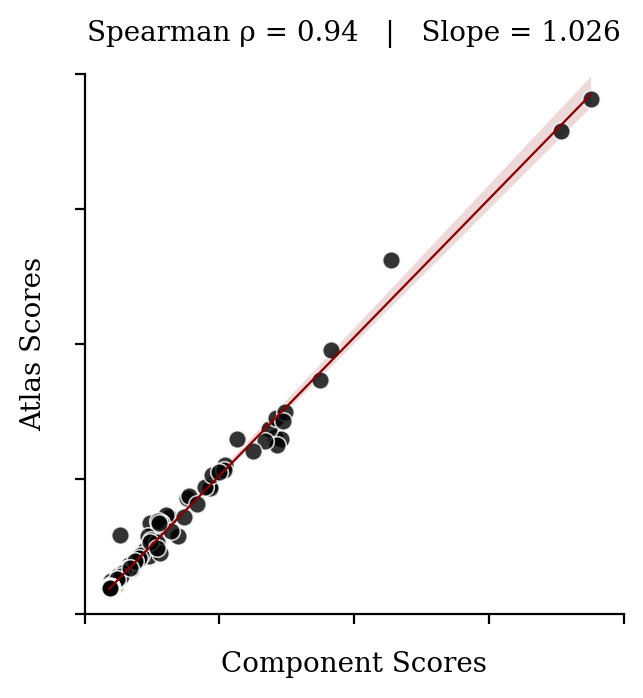

Slope: 1.0263, intercept: 0.7614


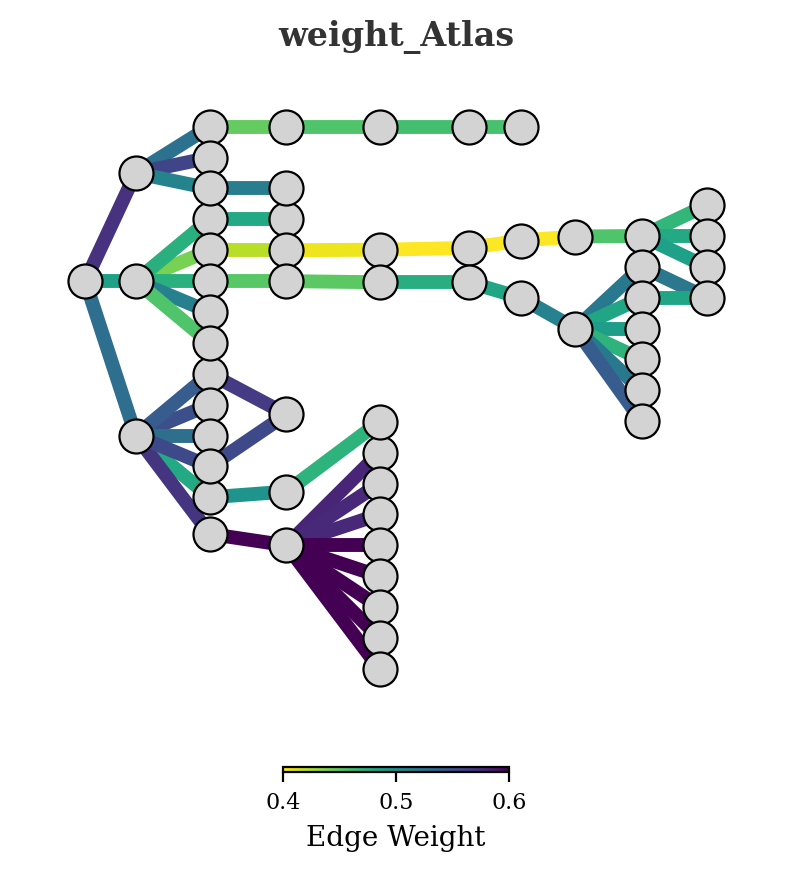

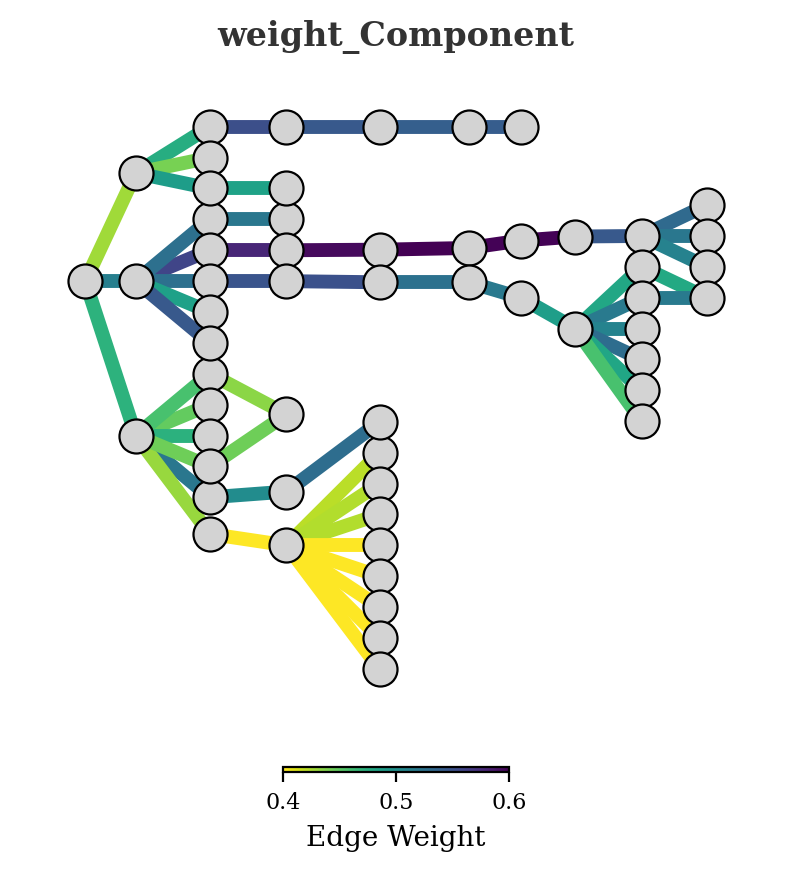

In [31]:
m, b = plot_correlation(df_both, "score_Component", "score_Atlas", "Component Scores", "Atlas Scores")
print(f"Slope: {m:.4f}, intercept: {b:.4f}")

for i in ['weight_Atlas', 'weight_Component']:
    plot_trajectory(
        trj, 
        figsize=(4, 5),
        edge_weight_attribute=i,
        title=i, 
        edge_vmin=0.4,
        edge_vmax=0.6,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=True
    )

/tmp/ipykernel_1291460/2055357023.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bp = sns.barplot(
/tmp/ipykernel_1291460/2055357023.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


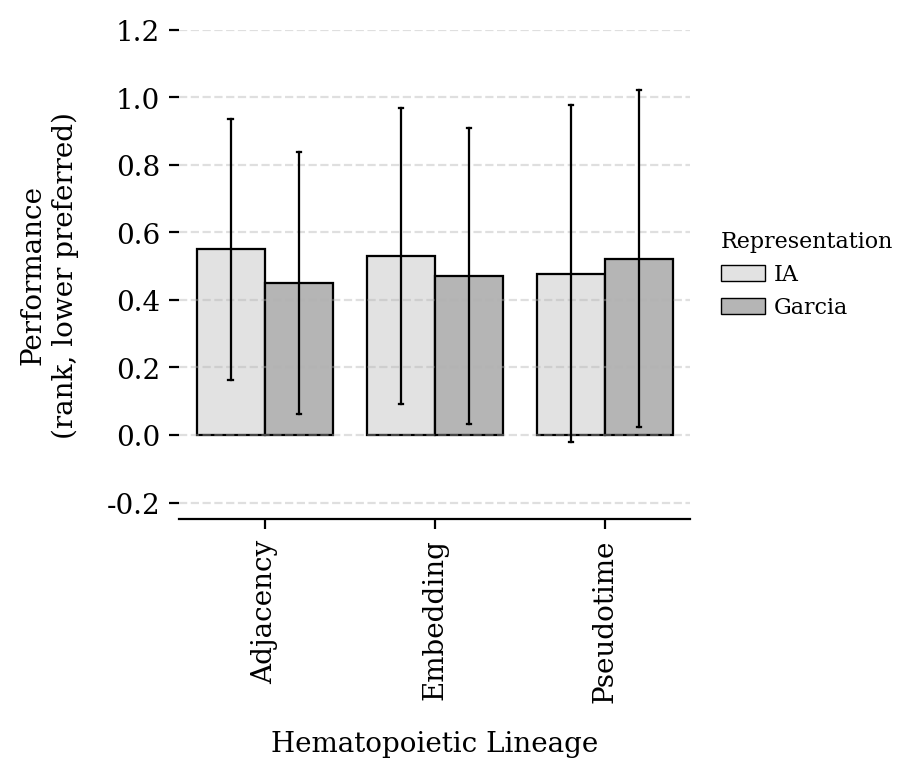

In [32]:
label_mapping = {
    "Atlas": "IA",
    "Component": "Garcia",
}

# match boxplot’s height & per-column width
fig_height = 4
n_cols = long_both["focus"].nunique()
col_width = 2.8
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=long_both,
    hue="focus",
    y="winner",
    x="path",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Hematopoietic Lineage', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(-0.25, 1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Representation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [33]:
long_both_haem = long_both.copy()

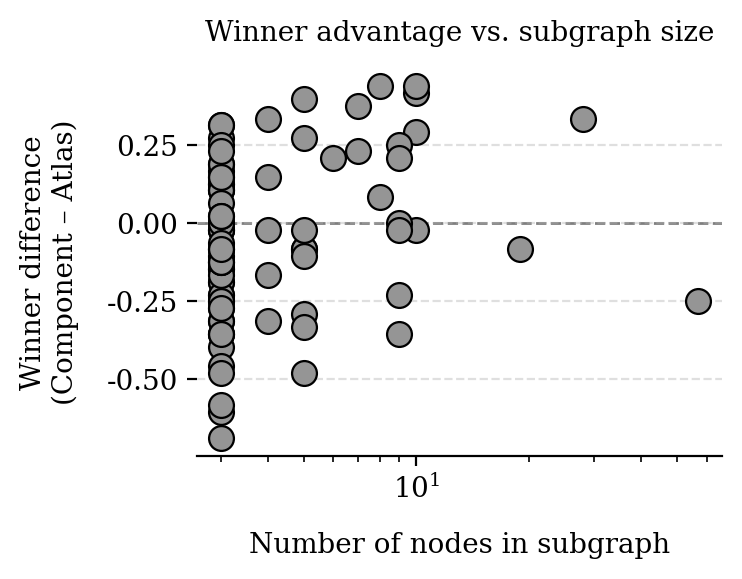

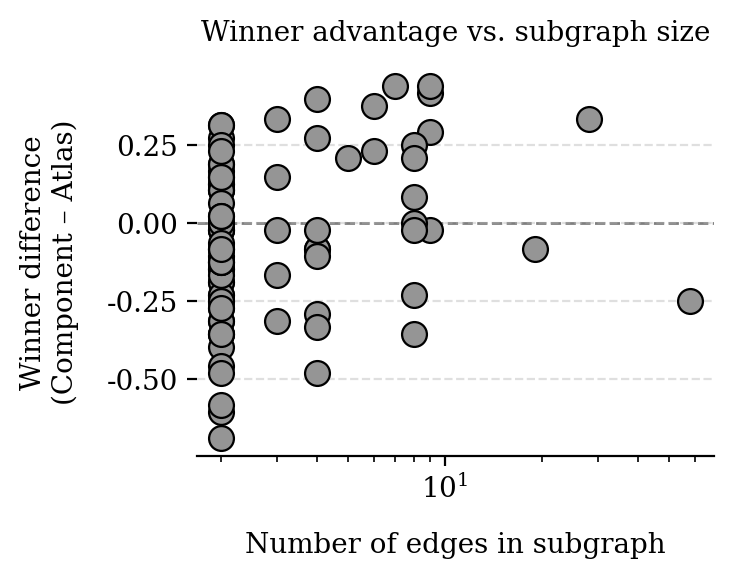

In [34]:
for what in ["nodes", "edges"]:
    fig_height = 3
    fig_width = 4.5  # Adjust as needed
    
    # Compute pivot as before
    pivot = (
        long_both
          .pivot_table(index=['booted_trajectory', f'len_{what}'],
                       columns='focus',
                       values='winner')
          .reset_index()
    )
    pivot['winner_diff'] = pivot['Component'] - pivot['Atlas']
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Draw scatter
    palette = sns.color_palette("Greys", n_colors=3)
    ax.scatter(pivot[f'len_{what}'], pivot['winner_diff'], s=80, 
               color=palette[1], edgecolor="black", linewidth=0.81, zorder=2)
    
    # Axes & labels
    ax.axhline(0, linestyle='--', linewidth=1, color='black', alpha=0.5, zorder=1)
    ax.set_xlabel(f"Number of {what} in subgraph", fontsize=10, labelpad=10)
    ax.set_ylabel("Winner difference\n(Component – Atlas)", fontsize=10, labelpad=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)
    ax.set_title("Winner advantage vs. subgraph size", fontsize=10, pad=10)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # Grid and despine
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(left=True, trim=False)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.xscale("log")
    plt.show()


# together

In [35]:
long_both2 = pd.concat([long_both_haem, long_both_germ])
long_both2.reset_index(drop=True, inplace=True)
long_both2["trajectory_class"] = long_both2["trajectory_class"].replace("Hematopoietic Lineage", "Hematopoietic")

/tmp/ipykernel_1291460/3031575451.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  bp = sns.barplot(
/tmp/ipykernel_1291460/3031575451.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


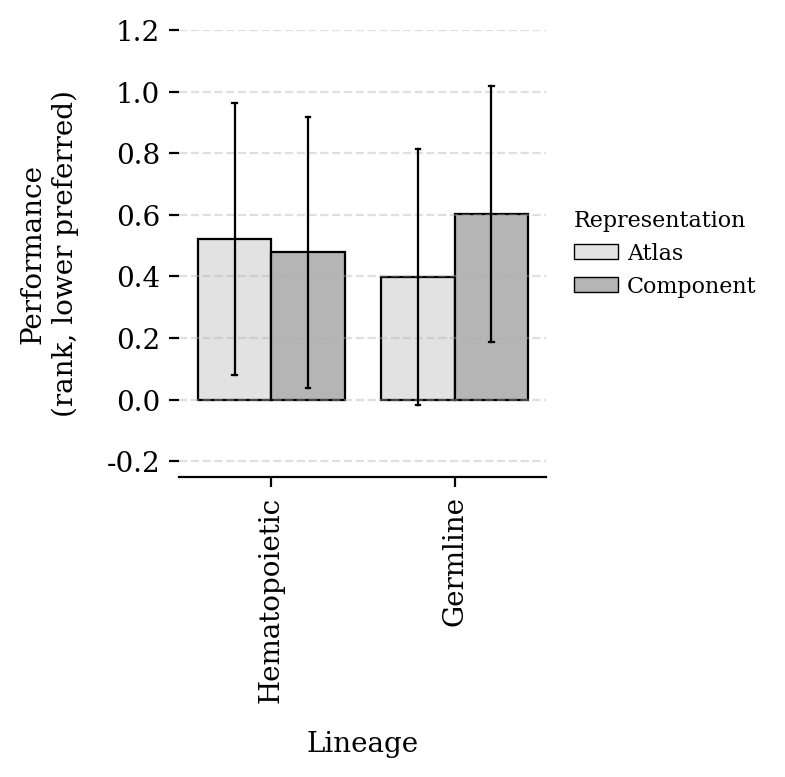

In [36]:
label_mapping = {
    "Atlas": "Atlas",
    "Component": "Component",
}

# match boxplot’s height & per-column width
fig_height = 4
n_cols = long_both2["focus"].nunique()
col_width = 2.4
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=long_both2,
    hue="focus",
    y="winner",
    x="trajectory_class",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Lineage', fontsize=10, labelpad=10)
plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)

ax.set_ylim(-0.25, 1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Representation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# UMAP germline

In [37]:
focus_trajectory = "germline"
decompose_method = "2"
input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{focus_trajectory}_litc_{decompose_method}.pkl")
with open(input_trajectories_path_litc, 'rb') as _file:
    lit = pickle.load(_file)
ann_lvl = ground_truth_trajectories_annotation_level[focus_trajectory]

In [38]:
adata_atlas = ad.read_h5ad(df_hdca_lvl3_adata_paths["scvi"]["latent"])
adata_atlas.obs = out_df
adata_atlas = adata_atlas[adata_atlas.obs[ann_lvl].isin(lit.nodes())]
adata_atlas

View of AnnData object with n_obs × n_vars = 11001 × 28
    obs: 'handle_anndata', 'study', 'sample_ID', 'organ', 'age', 'lane_ID', 'author_batch', 'institute', 'study_PI', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'anatomical_region', 'anatomical_region_level_2', 'sex', 'sex_inferred', 'subject_type', 'sample_status', 'sample_cultured', 'protocol_tissue_dissociation', 'cell_enrichment', 'library_platform', 'strand_sequence', 'sequencing_platform', 'reads_processing', 'biological_unit', 'reference_genome', 'reference_genome_ensembl_release', 'concatenated_integration_covariates', 'ref_anno2', 'original_author_annotation', 'ref_anno1', 'broad_anno', 'LVL3', 'LVL2', 'LVL1', 'LVL0'

In [39]:
adata_comp = ad.read_h5ad(df_hdca_component_adata_paths["Garcia"]["latent"])
adata_comp = ad.AnnData(X=adata_comp.X, obs=out_df.loc[adata_comp.obs.index].copy())
adata_comp = adata_comp[adata_comp.obs[ann_lvl].isin(lit.nodes())]
adata_comp

View of AnnData object with n_obs × n_vars = 10940 × 24
    obs: 'handle_anndata', 'study', 'sample_ID', 'organ', 'age', 'lane_ID', 'author_batch', 'institute', 'study_PI', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'anatomical_region', 'anatomical_region_level_2', 'sex', 'sex_inferred', 'subject_type', 'sample_status', 'sample_cultured', 'protocol_tissue_dissociation', 'cell_enrichment', 'library_platform', 'strand_sequence', 'sequencing_platform', 'reads_processing', 'biological_unit', 'reference_genome', 'reference_genome_ensembl_release', 'concatenated_integration_covariates', 'ref_anno2', 'original_author_annotation', 'ref_anno1', 'broad_anno', 'LVL3', 'LVL2', 'LVL1', 'LVL0'

In [40]:
print(adata_atlas.shape)
_temp_file_name = os.path.join(dataset_dir, f"anndata_hdca_input_germline_litc_comparison_atlas.h5ad")
print(_temp_file_name)
adata_atlas.write_h5ad(_temp_file_name)

(11001, 28)
/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/anndata_hdca_input_germline_litc_comparison_atlas.h5ad


In [41]:
print(adata_comp.shape)
_temp_file_name = os.path.join(dataset_dir, f"anndata_hdca_input_germline_litc_comparison_comp.h5ad")
print(_temp_file_name)
adata_comp.write_h5ad(_temp_file_name)

(10940, 24)
/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/anndata_hdca_input_germline_litc_comparison_comp.h5ad


In [42]:
sc.pp.neighbors(adata_atlas)
sc.tl.umap(adata_atlas)
sc.pp.neighbors(adata_comp)
sc.tl.umap(adata_comp)
# import warnings
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     sc.pl.umap(
#         adata_comp,
#         color=[ground_truth_trajectories_annotation_level[focus_trajectory]],
#         ncols=4,
#         frameon=False,
#         legend_fontsize="xx-small",
#         legend_loc="on data",
#     )

Sampling and flocking waypoints...
Time for determining waypoints: 0.024068339665730795 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6441711783409119 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/11001 [00:00<?, ?cell/s]

    Finish (0:00:05)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:03)


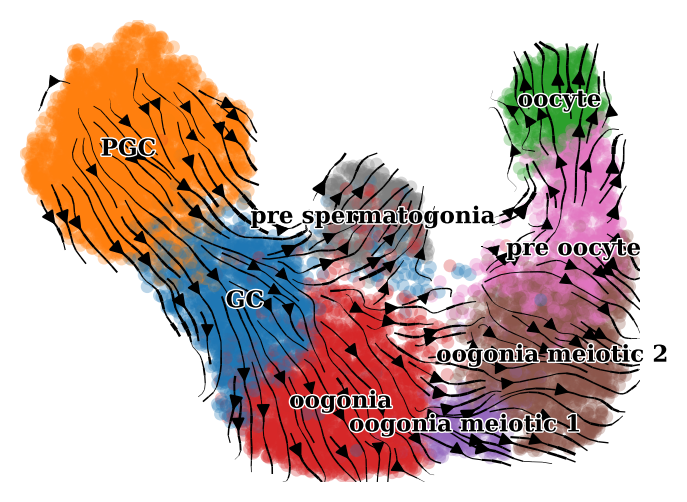

In [43]:
pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "PGC", i=10, ann_levl=ann_lvl)
plt.figure(figsize=(4,3))
pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="small")
plt.show()

Sampling and flocking waypoints...
Time for determining waypoints: 0.029937430222829183 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6106847167015076 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/10940 [00:00<?, ?cell/s]

    Finish (0:00:03)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


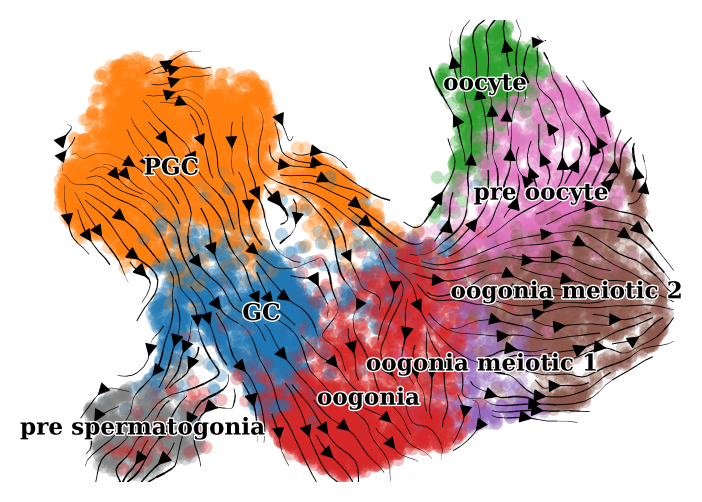

In [44]:
pk_adata_comp = cr_calc(adata_comp.copy(), root_cell_type = "PGC", i=10, ann_levl=ann_lvl)
plt.figure(figsize=(4,3))
pk_adata_comp.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="small")
plt.show()